
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [25]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs, load_marker_names_from_dir

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

marker_names = load_marker_names_from_dir(str(data_dir))

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [26]:
# from src.data.metadata import filter_graphs_by_metadata

# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     drop_values=["day4", "day4p5-more"],
# )

# print(f"After timepoint filter: {len(graphs)} organoids.")

In [27]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [28]:
from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)
# graphs = robust_zscore_organoid_targets(graphs, inplace=False)


In [29]:
from src.data.metadata import strip_graph_metadata
from src.data.splits import standardize_graph_targets, train_val_split_graphs

graphs = strip_graph_metadata(graphs, inplace=False)


# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

Split -> train: 705 | val: 176


In [30]:
from src.data.permutation import permute_graph_targets_within_organoid, permute_graph_features_within_organoid

g_train = permute_graph_features_within_organoid(g_train, inplace=False)
g_val = permute_graph_features_within_organoid(g_val, inplace=False)


In [31]:
center, scale = standardize_graph_targets(g_train, g_val, robust=True)

In [32]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=1e-3,
    batch_size=128,
    max_epochs=1000,
    patience=50,
    num_workers=4,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
from src.data.ring_features import attach_precomputed_ring_features

K_MAX = 9


g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd

from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP, PooledKHopMLP, RingSizeMLP
from src.models.io import save_model_checkpoint

depths = np.arange(0, K_MAX)

base_hidden_dim = 2*64
base_dropout = 0.1
base_norm = "batch"

trained_model_families = {
    "GIN": [],
    "ring": [],
    "ring-size": [],
    "ring-size (no center)": [],
}

param_rows = []

for family in trained_model_families.keys():

    for k in depths:
        print(f"\n=== Training {family} model with depth={k} ===")

        n_markers = int(g_train[0].x.size(1))

        if family == "GIN":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "train_eps": True,
            }
            model = GINCurvature(**model_kwargs)


        elif family == "ring":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "feature_attr": "x_ring",
            }
            model = RingFractionMLP(**model_kwargs)

        elif family == "ring-size":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
            }
            model = RingSizeMLP(**model_kwargs)

        elif family == "ring-size (no center)":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "use_center_markers": False,
            }
            model = RingSizeMLP(**model_kwargs)

        else:
            raise ValueError(f"Unknown family: {family}")

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_model_families[family].append(model)


=== Training GIN model with depth=0 ===
epoch 001 | train loss 1.4209 mae 1.0254 | val loss 1.2798 mae 1.0709
epoch 002 | train loss 1.2973 mae 1.0293 | val loss 1.1891 mae 1.0680
epoch 003 | train loss 1.2081 mae 1.0258 | val loss 1.1220 mae 1.0660
epoch 004 | train loss 1.1410 mae 1.0255 | val loss 1.0729 mae 1.0684
epoch 005 | train loss 1.0928 mae 1.0277 | val loss 1.0396 mae 1.0691
epoch 006 | train loss 1.0563 mae 1.0273 | val loss 1.0200 mae 1.0676
epoch 007 | train loss 1.0413 mae 1.0262 | val loss 1.0070 mae 1.0676
epoch 008 | train loss 1.0259 mae 1.0268 | val loss 1.0007 mae 1.0687
epoch 009 | train loss 1.0183 mae 1.0272 | val loss 0.9978 mae 1.0684
epoch 010 | train loss 1.0143 mae 1.0266 | val loss 0.9965 mae 1.0679
epoch 011 | train loss 1.0141 mae 1.0267 | val loss 0.9959 mae 1.0681
epoch 012 | train loss 1.0110 mae 1.0267 | val loss 0.9955 mae 1.0683
epoch 013 | train loss 1.0110 mae 1.0268 | val loss 0.9951 mae 1.0681
epoch 014 | train loss 1.0109 mae 1.0266 | val lo

In [35]:
from src.analysis.prediction_analysis import eval_model_per_marker

def evaluate_family_models(trained_models, eval_subgraphs, device, scale, center):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        # aggregate storage
        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_marker(
                model,
                eval_subgraphs,
                device,
                scale,
                center,
                center_only=False,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        # stack aggregate arrays across model depth / family member index
        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                vals = fam_aggregate[agg_name][metric]
                fam_aggregate_stacked[agg_name][metric] = np.asarray(vals, dtype=float)

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results


eval_results = evaluate_family_models(
    trained_models=trained_model_families,
    eval_subgraphs=g_val,
    device=device,
    scale=scale,
    center=center,
)

/home/fmoller/Projects/LearningOrganoids/GraphNN/src/analysis/prediction_analysis.py:123: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(var_s, res_model**2)


In [36]:
# import copy
# import torch
# from torch_geometric.utils import degree

# from src.models.gnn import GINCurvature


# def make_feature_variant(
#     graphs,
#     *,
#     use_markers=True,
#     use_degree=False,
#     degree_as_float=True,
# ):
#     """
#     Return shallow copies of graphs with modified node features:
#       - markers only
#       - markers + degree
#       - degree only
#     """
#     if not use_markers and not use_degree:
#         raise ValueError("At least one of use_markers or use_degree must be True.")

#     graphs_out = [copy.copy(g) for g in graphs]

#     for g in graphs_out:
#         x_parts = []

#         if use_markers:
#             x_parts.append(g.x.float())

#         if use_degree:
#             deg = degree(g.edge_index[0], num_nodes=g.x.size(0)).unsqueeze(1)
#             if degree_as_float:
#                 deg = deg.float()
#             x_parts.append(deg)

#         g.x = torch.cat(x_parts, dim=1)

#     return graphs_out


# # ------------------------------------------------------------
# # Build feature variants
# # ------------------------------------------------------------
# g_train_markdeg = make_feature_variant(g_train, use_markers=True,  use_degree=True)
# g_val_markdeg   = make_feature_variant(g_val,   use_markers=True,  use_degree=True)

# # ------------------------------------------------------------
# # Train the two extra GIN families
# # ------------------------------------------------------------
# trained_extra_families = {
#     "GIN+degree": [],
# }

# for family in trained_extra_families.keys():
#     for k in depths:
#         print(f"\n=== Training {family} model with depth={k} ===")

#         if family == "GIN+degree":
#             train_graphs = g_train_markdeg
#             val_graphs = g_val_markdeg
#         else:
#             raise ValueError(f"Unknown family: {family}")

#         n_features = int(train_graphs[0].x.size(1))

#         model_kwargs = {
#             "n_markers": n_features,
#             "hidden_dim": base_hidden_dim,
#             "num_layers": int(k),
#             "dropout": base_dropout,
#             "residual": True,
#             "norm": base_norm,
#             "train_eps": True,
#         }

#         model = GINCurvature(**model_kwargs)
#         model, metrics, history = train(model, train_graphs, val_graphs, cfg)
#         trained_extra_families[family].append(model)

# # ------------------------------------------------------------
# # Evaluate the extra families
# # ------------------------------------------------------------
# eval_results_markdeg = evaluate_family_models(
#     trained_models={"GIN+degree": trained_extra_families["GIN+degree"]},
#     eval_subgraphs=g_val_markdeg,
#     device=device,
#     scale=scale,
#     center=center,
# )


# # ------------------------------------------------------------
# # Append into existing eval_results so everything can be plotted together
# # ------------------------------------------------------------
# eval_results.update(eval_results_markdeg)

# print("Added families to eval_results:", ["GIN+degree"])
# print("All families now:", list(eval_results.keys()))

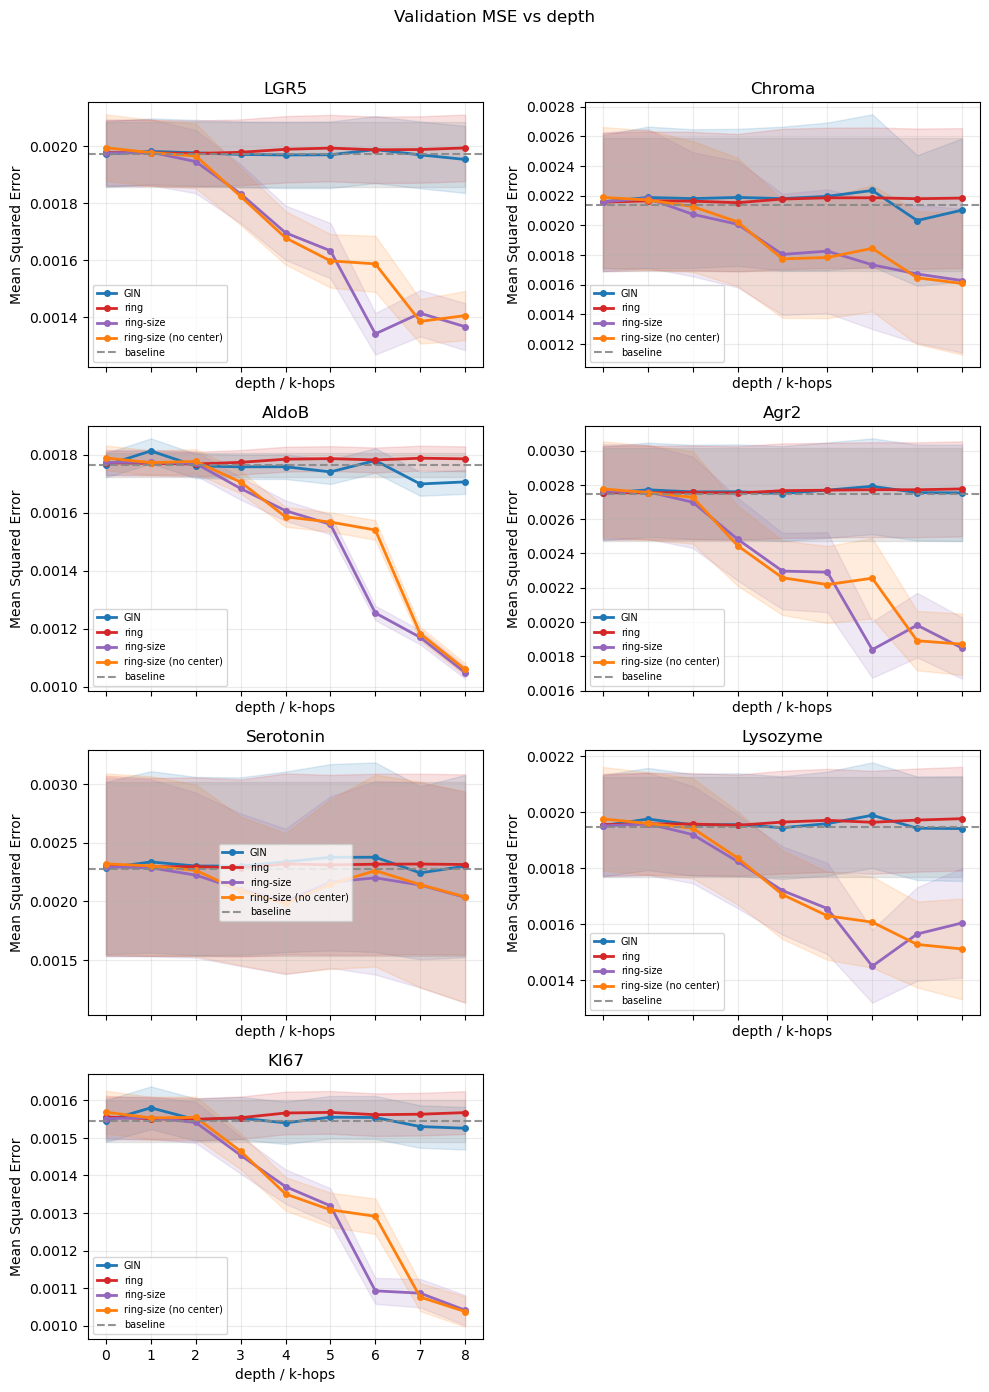

In [37]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GIN": "#1f77b4",
    # "GIN+degree": "#e377c2",
    "ring":      "#d62728",
    "ring-size": "#9467bd",
    "ring-size (no center)":       "#ff7f0e",
}


family_order = [
    "GIN",
    # "GIN+degree",
    "ring",
    "ring-size",
    "ring-size (no center)",
]



plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

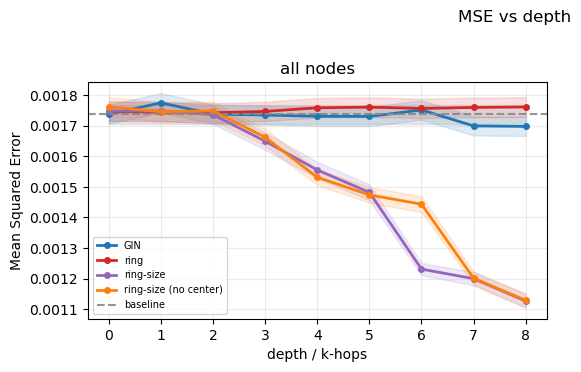

In [38]:
plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

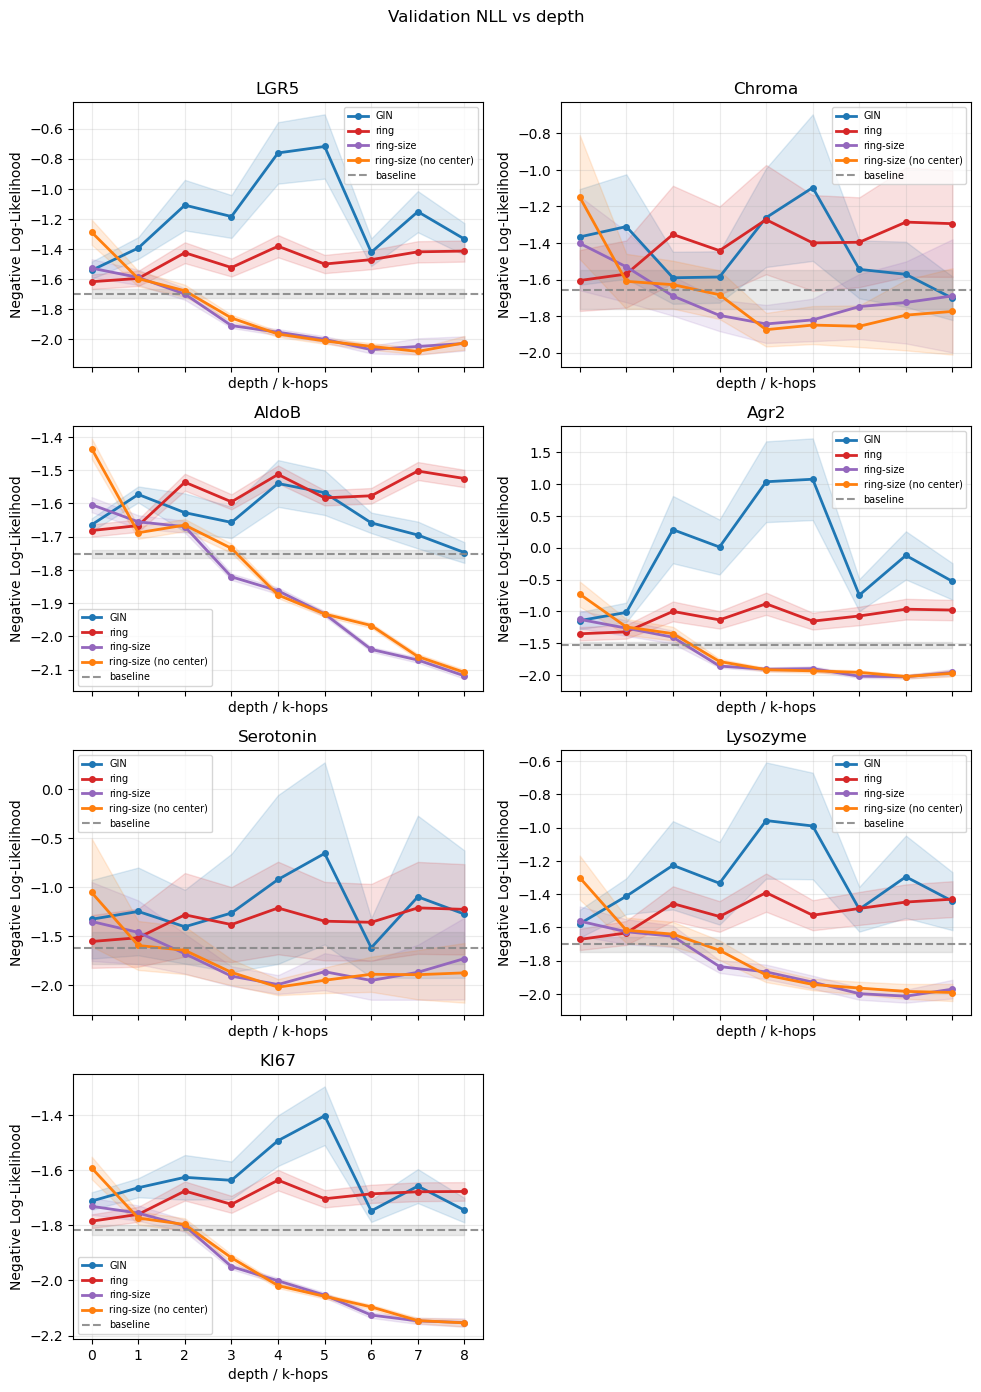

In [39]:
plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

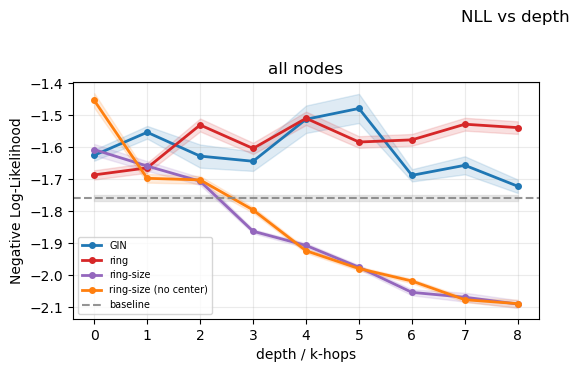

In [40]:
plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

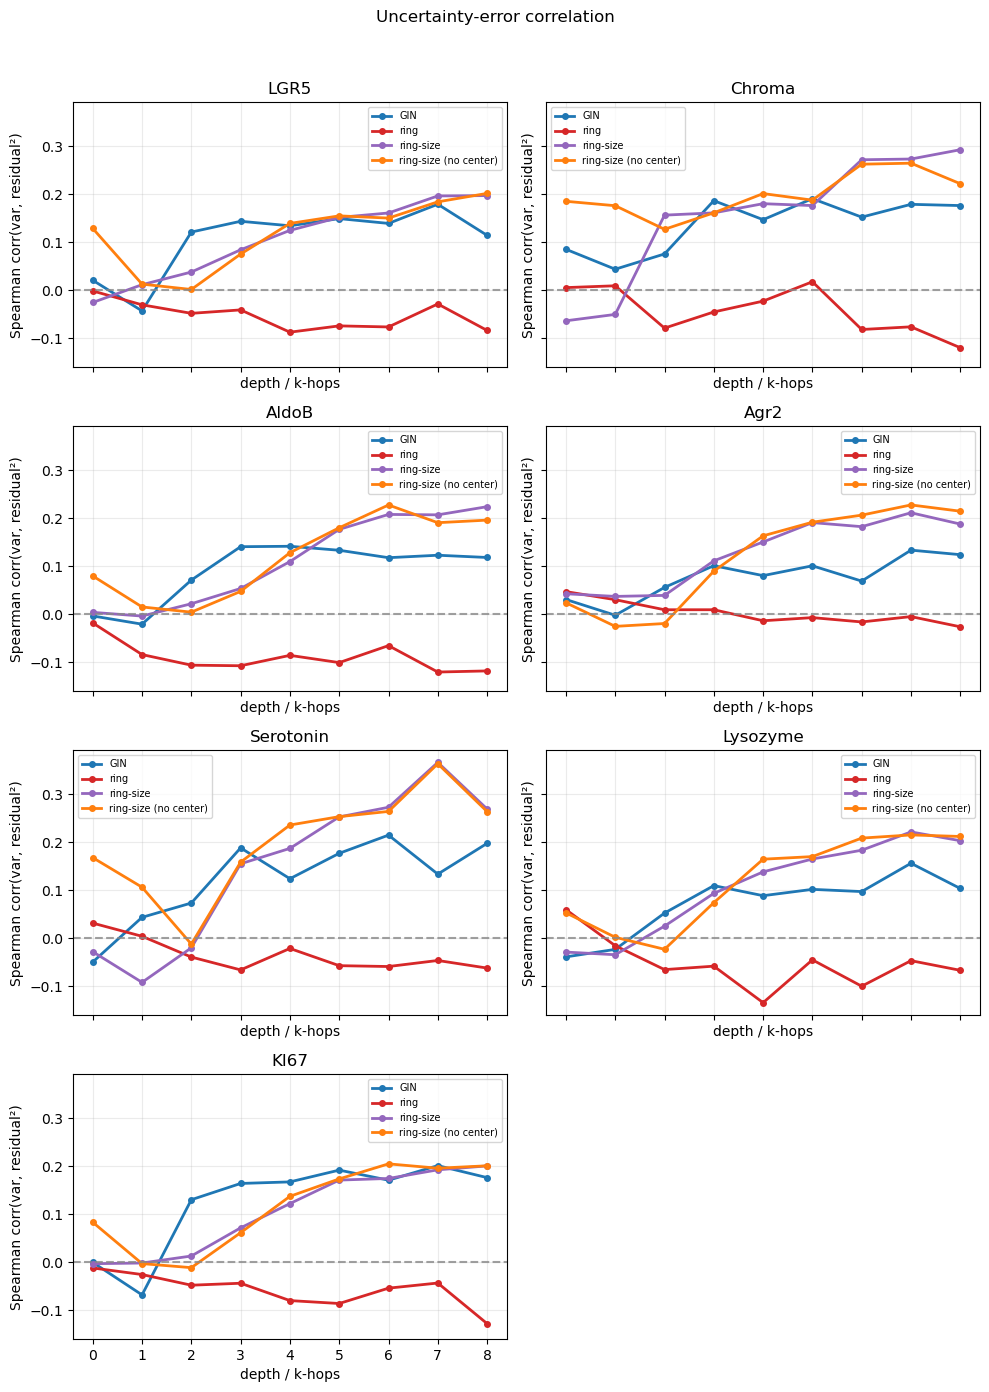

In [41]:

plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
plt.show()

(<Figure size 1040x360 with 2 Axes>,
 array([<Axes: title={'center': 'all nodes'}, xlabel='depth / k-hops', ylabel='Spearman corr(var, residual²)'>,
        <Axes: >], dtype=object))

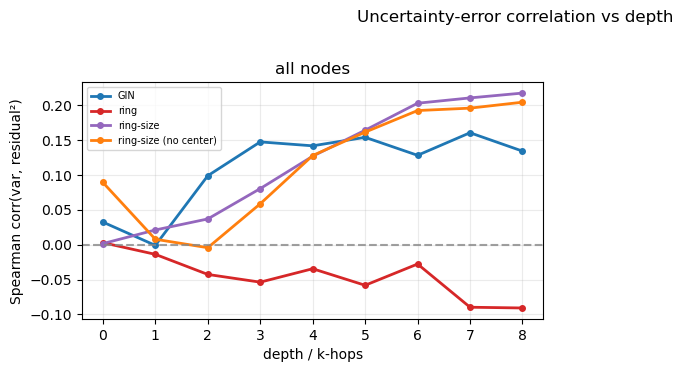

In [42]:
plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)

In [43]:
import json
import pickle
from pathlib import Path
from datetime import datetime


def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Saved joint experiment → {save_dir}")

In [44]:
joint_config = {
    "experiment_group": "permutation_test",

    "model_families": list(trained_model_families.keys()),
    "depths": depths.tolist(),

    "hidden_dim": base_hidden_dim,
    "dropout": base_dropout,
    "norm": base_norm,
    "K_MAX": K_MAX,

    "train_config": {
        "loss_name": cfg.loss_name,
        "lr": cfg.lr,
        "batch_size": cfg.batch_size,
        "max_epochs": cfg.max_epochs,
        "patience": cfg.patience,
        "num_workers": cfg.num_workers,
    },

    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),

    "marker_names": list(marker_names),
}

In [ ]:
# results_by_experiment = {
#     "eval_results": eval_results,
# }

# save_dir = PROJECT_ROOT / "results_experiments" / "permutation_tests" / "run_003"

# save_joint_experiment(
#     save_dir=save_dir,
#     config=joint_config,
#     results_by_experiment=results_by_experiment,
#     notes="Compare model when trained and evaluated on feature permuted graphs",
# )

Saved joint experiment → /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/run_003
